![image.png](https://i.imgur.com/a3uAqnb.png)

# 🎨 Image Generation using Generative Adversarial Networks (GANs)

GANs were introduced in 2014 by Ian Goodfellow and his team.

A GAN has two models:

* 👨‍🎨 **Generator:** creates fake images.
* 🕵️‍♂️ **Discriminator:** decides whether an image is real or fake.

During training, the generator tries to create better images, while the discriminator tries to detect them.

Ideally, the generator becomes so good that the discriminator cannot tell the difference between real and fake images, so it gives a result close to 50%.


![gan image](https://i.imgur.com/Ed5ZMfR.png)

<p align = "center">
Fig.1 - GAN Architecture  
(<a href="https://github.com/JamesAllingham/LaTeX-TikZ-Diagrams">
source
</a>)
</p>

In [4]:
import os
from glob import glob

import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn

from PIL import Image
from mpl_toolkits.axes_grid1 import ImageGrid
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from tqdm.auto import tqdm

/home/lama/miniconda3/envs/rtx5070/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
EPOCHS = 50
LEARNING_RATE = 1e-4
BATCH_SIZE = 64
LATENT_DIM = 100
IMAGE_SIZE = 64

## 1- Loading the Anime Face Dataset

In [6]:
# Download latest version
path = kagglehub.dataset_download("splcher/animefacedataset")
print("Path to dataset files:", path)

Path to dataset files: /home/lama/.cache/kagglehub/datasets/splcher/animefacedataset/versions/3


In [7]:
class AnimeFaceDataset(Dataset):
    def __init__(self, folder, transform=None):
        self.files = glob(folder + "/**/*.jpg", recursive=True)
        self.transform = transform

    def __len__(self):
        return len(self.files)

    def __getitem__(self, index):
        image = Image.open(self.files[index]).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image

### 2-Image Preprocessing Pipeline

Before training, we prepare the images using three steps:

1. **Resize:** Resize all images to `64 × 64`.
2. **ToTensor:** Convert the images into PyTorch tensors.
3. **Normalize:** Change pixel values from `[0, 1]` to `[-1, 1]`.

> **Question:** Why do we normalize the images to `[-1, 1]`?


In [8]:
transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.5, 0.5, 0.5),
        std=(0.5, 0.5, 0.5)
    )
])

anime_dataset = AnimeFaceDataset(path, transform)

train_dataloader = DataLoader(
    anime_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2
)

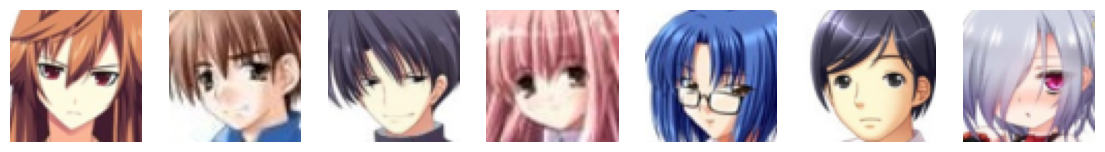

In [9]:
images = next(iter(train_dataloader))

plt.figure(figsize=(14, 3))

for i in range(7):
    image = images[i]
    image = (image + 1) / 2          # Convert [-1, 1] to [0, 1]
    image = image.permute(1, 2, 0)   # CHW → HWC

    plt.subplot(1, 7, i + 1)
    plt.imshow(image)
    plt.axis("off")

plt.show()

In [10]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

## 3 - Building the Generator

The Generator creates new images from random noise.

It receives a random vector with `100` values and gradually transforms it into a `64 × 64` RGB image.

### Generator Architecture

1. **Input:** A random noise vector with size `100`.
2. **Upsampling:** `ConvTranspose2d` layers gradually increase the image size.
3. **Batch Normalization:** Helps make training more stable.
4. **Activation:** `ReLU` is used between layers.
5. **Output:** `Tanh` produces pixel values between `-1` and `1`.




In [11]:
# Weight initialization recommended for DCGAN
def weights_init(layer):
    if isinstance(layer, (nn.Conv2d, nn.ConvTranspose2d)):
        nn.init.normal_(layer.weight, mean=0.0, std=0.02)

    elif isinstance(layer, (nn.BatchNorm1d, nn.BatchNorm2d)):
        nn.init.normal_(layer.weight, mean=1.0, std=0.02)
        nn.init.constant_(layer.bias, 0)


class Generator(nn.Module):
    def __init__(self, latent_dim=100):
        super().__init__()

        self.model = nn.Sequential(
            # 1 × 1 → 4 × 4
            nn.ConvTranspose2d(
                latent_dim, 512, kernel_size=4,
                stride=1, padding=0, bias=False
            ),
            nn.BatchNorm2d(512),
            nn.ReLU(True),

            # 4 × 4 → 8 × 8
            nn.ConvTranspose2d(512, 256, 4, 2, 1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(True),

            # 8 × 8 → 16 × 16
            nn.ConvTranspose2d(256, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(True),

            # 16 × 16 → 32 × 32
            nn.ConvTranspose2d(128, 64, 4, 2, 1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(True),

            # 32 × 32 → 64 × 64
            nn.ConvTranspose2d(64, 3, 4, 2, 1, bias=False),
            nn.Tanh()
        )

    def forward(self, noise):
        # Convert shape from [batch, latent_dim]
        # to [batch, latent_dim, 1, 1]
        noise = noise.view(noise.size(0), noise.size(1), 1, 1)
        return self.model(noise)


generator = Generator(LATENT_DIM)
generator.apply(weights_init)

Generator(
  (model): Sequential(
    (0): ConvTranspose2d(100, 512, kernel_size=(4, 4), stride=(1, 1), bias=False)
    (1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ConvTranspose2d(512, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (4): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (7): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU(inplace=True)
    (9): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (10): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): ReLU(inplace=True)
    (12): ConvTranspose2d(64, 3, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (13): Tanh()
  )
)

### 4- The Discriminator

The Discriminator receives an image and decides whether it is **real** or **fake**.

It takes a `64 × 64` RGB image and gradually reduces its size while extracting important visual features.

### Discriminator Architecture

1. **Input:** An RGB image with shape `3 × 64 × 64`.
2. **Downsampling:** `Conv2d` layers reduce the image size.
3. **Feature Extraction:** The number of channels increases as the image becomes smaller.
4. **Batch Normalization:** Helps stabilize training.
5. **Activation:** `LeakyReLU` allows small negative values and helps gradients continue flowing.
6. **Output:** The final layer produces one value called a **logit**, which represents whether the image is real or fake.

> **Question:** Why does the Discriminator reduce the image size while increasing the number of feature channels?


In [12]:
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()

        self.model = nn.Sequential(
            # 3 × 64 × 64 → 64 × 32 × 32
            nn.Conv2d(3, 64, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),

            # 64 × 32 × 32 → 128 × 16 × 16
            nn.Conv2d(64, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),

            # 128 × 16 × 16 → 256 × 8 × 8
            nn.Conv2d(128, 256, 4, 2, 1, bias=False),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),

            # 256 × 8 × 8 → 512 × 4 × 4
            nn.Conv2d(256, 512, 4, 2, 1, bias=False),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2, inplace=True),

            # 512 × 4 × 4 → 1
            nn.Conv2d(512, 1, 4, 1, 0, bias=False)
        )

    def forward(self, image):
        output = self.model(image)
        return output.view(image.size(0))


discriminator = Discriminator()
discriminator.apply(weights_init)

Discriminator(
  (model): Sequential(
    (0): Conv2d(3, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (4): LeakyReLU(negative_slope=0.2, inplace=True)
    (5): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (6): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): LeakyReLU(negative_slope=0.2, inplace=True)
    (8): Conv2d(256, 512, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (9): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): LeakyReLU(negative_slope=0.2, inplace=True)
    (11): Conv2d(512, 1, kernel_size=(4, 4), stride=(1, 1), bias=False)
  )
)

In [13]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

generator = generator.to(device)
discriminator = discriminator.to(device)

print("Using device:", device)

Using device: cuda


###  5- Loss Function and Optimizers

* **Loss:** We use `BCEWithLogitsLoss` to classify images as real (`1`) or fake (`0`). It combines the sigmoid function and binary cross-entropy loss in a more stable way.

* **Optimizers:** We use the Adam optimizer for both the Generator and Discriminator with `beta1 = 0.5`, which is commonly used in DCGAN training.


In [14]:
# Loss function
loss_fn = nn.BCEWithLogitsLoss()

# Optimizers
optimizer_gen = torch.optim.Adam(
    generator.parameters(),
    lr=LEARNING_RATE,
    betas=(0.5, 0.999)
)

optimizer_disc = torch.optim.Adam(
    discriminator.parameters(),
    lr=LEARNING_RATE,
    betas=(0.5, 0.999)
)

##  6- Training
### Step 1: Train the Discriminator

The Discriminator learns to distinguish real images from generated images.

For each batch:

1. Real images are assigned the target `1`.
2. Fake images are assigned the target `0`.
3. The real and fake losses are added together.
4. Only the Discriminator’s weights are updated.

The Generator’s output is detached during this step so that the Generator is not updated.


In [15]:
def train_discriminator(real_images):
    batch_size = real_images.size(0)

    real_targets = torch.ones(batch_size, device=device)
    fake_targets = torch.zeros(batch_size, device=device)

    optimizer_disc.zero_grad(set_to_none=True)

    # Discriminator loss on real images
    real_logits = discriminator(real_images)
    loss_real = loss_fn(real_logits, real_targets)

    # Generate fake images
    noise = torch.randn(batch_size, LATENT_DIM, device=device)
    fake_images = generator(noise)

    # Discriminator loss on fake images
    fake_logits = discriminator(fake_images.detach())
    loss_fake = loss_fn(fake_logits, fake_targets)

    # Total discriminator loss
    loss_disc = loss_real + loss_fake

    loss_disc.backward()
    optimizer_disc.step()

    return loss_disc, fake_images

### Step 2: Train the Generator 👨‍🎨

The Generator learns to create images that fool the Discriminator.

Although the images are fake, we assign them the target `1` because the Generator wants the Discriminator to classify them as real.

During this step:

1. Fake images are passed through the Discriminator.
2. Their target is set to `1`.
3. The loss is backpropagated through the Discriminator to the Generator.
4. Only the Generator’s weights are updated.


In [16]:
def train_generator(fake_images):
    batch_size = fake_images.size(0)

    # The Generator wants fake images classified as real
    real_targets = torch.ones(batch_size, device=device)

    optimizer_gen.zero_grad(set_to_none=True)

    # Freeze Discriminator weights
    for parameter in discriminator.parameters():
        parameter.requires_grad_(False)

    fake_logits = discriminator(fake_images)
    loss_gen = loss_fn(fake_logits, real_targets)

    loss_gen.backward()
    optimizer_gen.step()

    # Unfreeze Discriminator weights
    for parameter in discriminator.parameters():
        parameter.requires_grad_(True)

    return loss_gen

### Step 3: Alternate Between Both Models

For every batch of real images, we perform two updates:

1. Train the **Discriminator** using real and fake images.
2. Train the **Generator** using the Discriminator’s feedback.

This alternating process continues for several epochs. We also record both losses so we can visualize the training progress later.


In [17]:
generator_losses = []
discriminator_losses = []

for epoch in range(EPOCHS):
    progress_bar = tqdm(train_dataloader)

    for real_images in progress_bar:
        real_images = real_images.to(device)

        # Step 1: Train the Discriminator
        loss_disc, fake_images = train_discriminator(real_images)

        # Step 2: Train the Generator
        loss_gen = train_generator(fake_images)

        # Save losses
        discriminator_losses.append(loss_disc.item())
        generator_losses.append(loss_gen.item())

        progress_bar.set_description(
            f"Epoch {epoch + 1}/{EPOCHS}"
        )

        progress_bar.set_postfix({
            "D Loss": f"{loss_disc.item():.3f}",
            "G Loss": f"{loss_gen.item():.3f}"
        })

Epoch 50/50: 100%|██████████| 994/994 [00:19<00:00, 51.26it/s, D Loss=0.042, G Loss=4.557] 


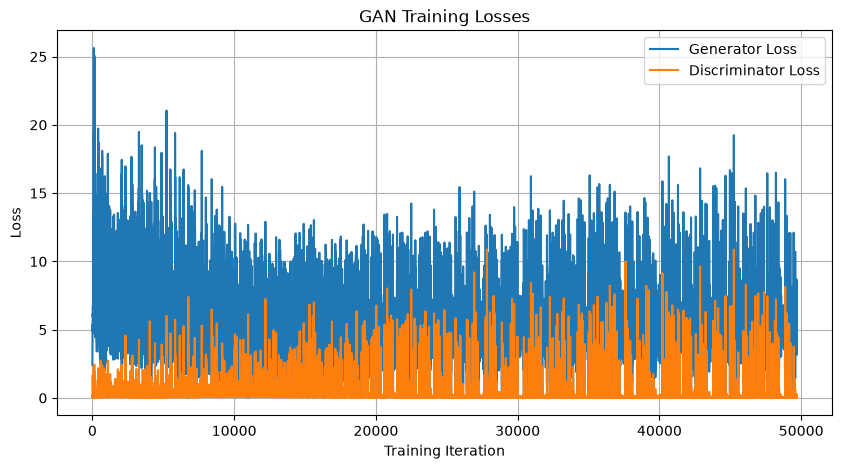

In [21]:
plt.figure(figsize=(10, 5))

plt.plot(generator_losses, label="Generator Loss")
plt.plot(discriminator_losses, label="Discriminator Loss")

plt.xlabel("Training Iteration")
plt.ylabel("Loss")
plt.title("GAN Training Losses")
plt.legend()
plt.grid(True)
plt.show()

## 7-Generating New Images

Now that the GAN has been trained, we can sample new random noise vectors and pass them through the Generator to create new anime faces.

Each different noise vector produces a different generated image.


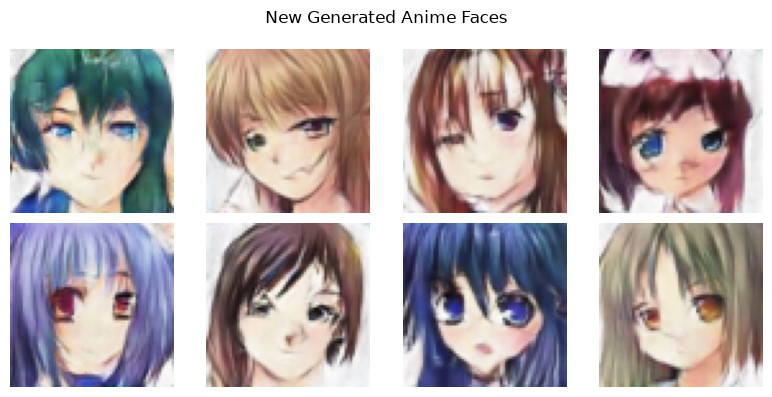

Generator(
  (model): Sequential(
    (0): ConvTranspose2d(100, 512, kernel_size=(4, 4), stride=(1, 1), bias=False)
    (1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ConvTranspose2d(512, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (4): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (7): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU(inplace=True)
    (9): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (10): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): ReLU(inplace=True)
    (12): ConvTranspose2d(64, 3, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (13): Tanh()
  )
)

In [22]:
generator.eval()

num_images = 8
new_noise = torch.randn(num_images, LATENT_DIM, device=device)

with torch.no_grad():
    new_images = generator(new_noise).cpu()

plt.figure(figsize=(8, 4))

for i in range(num_images):
    image = (new_images[i] + 1) / 2      # [-1, 1] → [0, 1]
    image = image.permute(1, 2, 0)       # CHW → HWC

    plt.subplot(2, 4, i + 1)
    plt.imshow(image.clamp(0, 1))
    plt.axis("off")

plt.suptitle("New Generated Anime Faces")
plt.tight_layout()
plt.show()

generator.train()

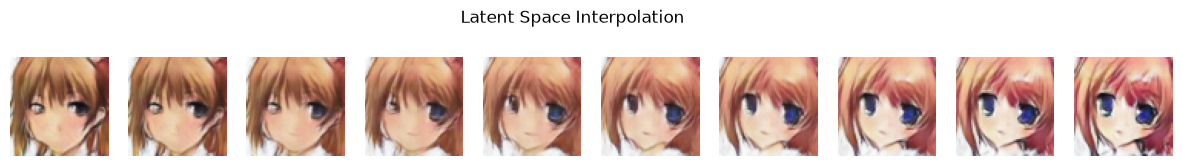

Generator(
  (model): Sequential(
    (0): ConvTranspose2d(100, 512, kernel_size=(4, 4), stride=(1, 1), bias=False)
    (1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ConvTranspose2d(512, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (4): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (7): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU(inplace=True)
    (9): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (10): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): ReLU(inplace=True)
    (12): ConvTranspose2d(64, 3, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (13): Tanh()
  )
)

In [23]:
generator.eval()

z1 = torch.randn(1, LATENT_DIM, device=device)
z2 = torch.randn(1, LATENT_DIM, device=device)

steps = 10
interpolated_noise = []

for alpha in torch.linspace(0, 1, steps, device=device):
    z = (1 - alpha) * z1 + alpha * z2
    interpolated_noise.append(z)

interpolated_noise = torch.cat(interpolated_noise)

with torch.no_grad():
    images = generator(interpolated_noise).cpu()

plt.figure(figsize=(15, 2))

for i, image in enumerate(images):
    image = (image + 1) / 2
    image = image.permute(1, 2, 0)

    plt.subplot(1, steps, i + 1)
    plt.imshow(image.clamp(0, 1))
    plt.axis("off")

plt.suptitle("Latent Space Interpolation")
plt.show()

generator.train()

### Contributed by: Ali Habibullah, Updated by Lama 